# IMDb Movie Reviews Sentiment Analysis

## Exploratory Data Analysis (EDA)

**Author:** Your Name

**Dataset:** IMDb 50K Movie Reviews

**Goal:** Analyze movie reviews before building machine learning models.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Better looking plots
plt.style.use("ggplot")

# Display all columns if needed
pd.set_option("display.max_columns", None)

In [1]:
print("Hello, Notebook!")

Hello, Notebook!


In [3]:
df = pd.read_csv("../data/IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.shape

(50000, 2)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 63.6 MB


In [6]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(418)

In [8]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

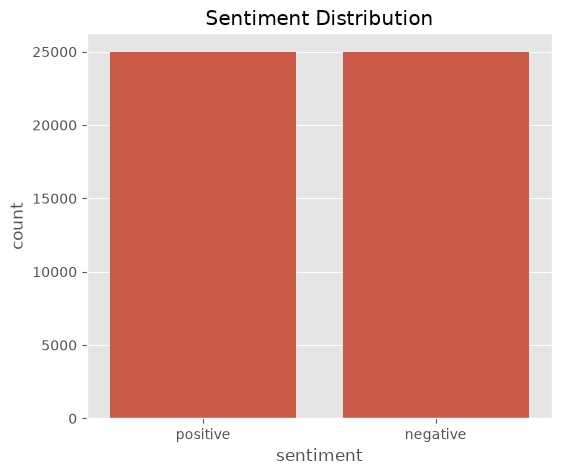

In [9]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="sentiment"
)

plt.title("Sentiment Distribution")

plt.show()

In [10]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [13]:
df["review_length"].describe()

count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: review_length, dtype: float64

In [12]:
df["review_length"] = df["review"].str.len()

df.head()

,review,sentiment,review_length
0,One of the other reviewers has mentioned that ...,positive,1761
1,A wonderful little production. <br /><br />The...,positive,998
2,I thought this was a wonderful way to spend ti...,positive,926
3,Basically there's a family where a little boy ...,negative,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317


In [14]:
df.groupby("sentiment")["review_length"].mean()

sentiment
negative    1294.06436
positive    1324.79768
Name: review_length, dtype: float64

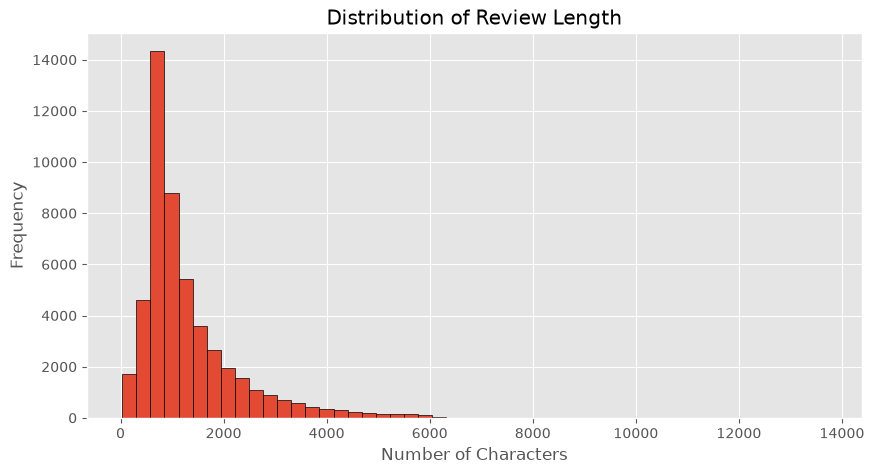

In [15]:
plt.figure(figsize=(10,5))

plt.hist(
    df["review_length"],
    bins=50,
    edgecolor="black"
)

plt.title("Distribution of Review Length")

plt.xlabel("Number of Characters")

plt.ylabel("Frequency")

plt.show()

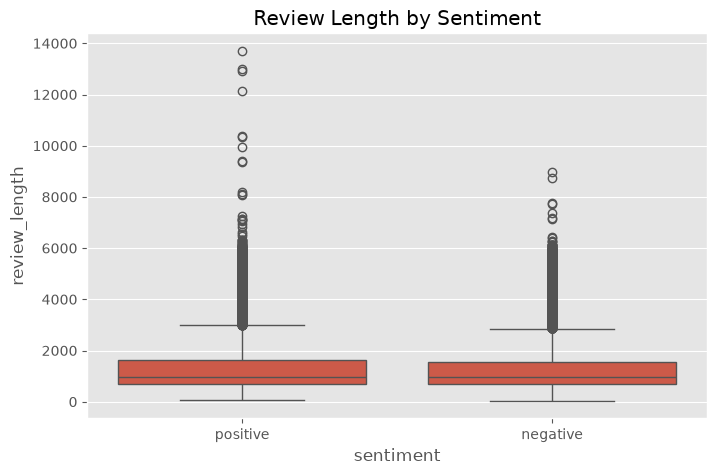

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="sentiment",
    y="review_length"
)

plt.title("Review Length by Sentiment")

plt.show()

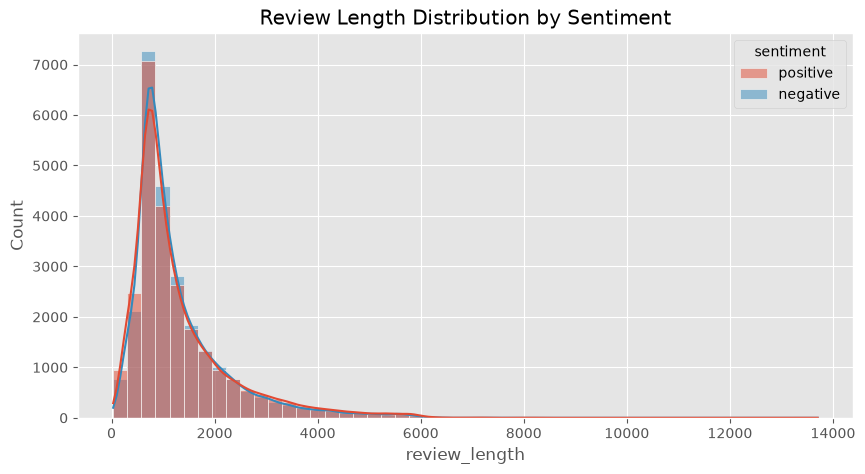

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="review_length",
    hue="sentiment",
    bins=50,
    kde=True
)

plt.title("Review Length Distribution by Sentiment")

plt.show()

In [18]:
df.nlargest(
    5,
    "review_length"
)[["sentiment", "review_length"]]

,sentiment,review_length
31481,positive,13704
40521,positive,12988
31240,positive,12930
31436,positive,12129
5708,positive,10363


In [19]:
df.nsmallest(
    5,
    "review_length"
)[["sentiment", "review_length"]]

,sentiment,review_length
27521,negative,32
31072,negative,41
40817,negative,49
28920,negative,51
19874,negative,52


In [20]:
df.to_csv(
    "../data/imdb_with_length.csv",
    index=False
)

In [21]:
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
import re

## Word Cloud for Positive Reviews

A word cloud displays the most frequently occurring words in positive movie reviews. Larger words indicate higher frequency.

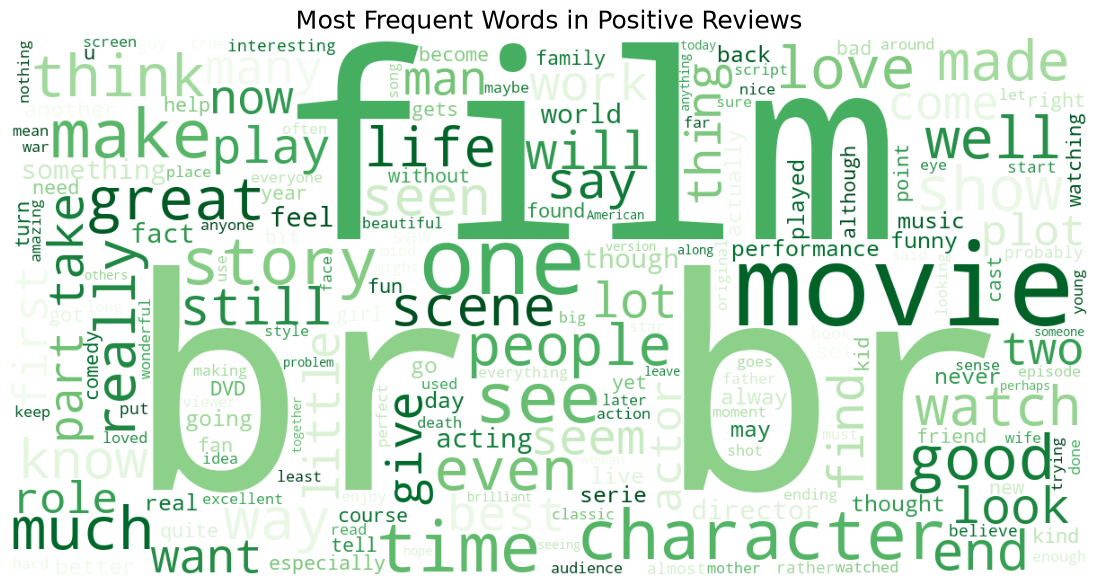

In [22]:
positive_reviews = " ".join(
    df[df["sentiment"] == "positive"]["review"]
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="Greens"
).generate(positive_reviews)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Frequent Words in Positive Reviews", fontsize=18)

plt.show()

### Observation

The positive review word cloud is dominated by words such as *movie*, *film*, *one*, *good*, and *great*. This indicates that reviewers frequently use positive descriptive words while discussing the overall quality of the movie.

## Word Cloud for Negative Reviews

This visualization highlights the words that appear most frequently in negative movie reviews.

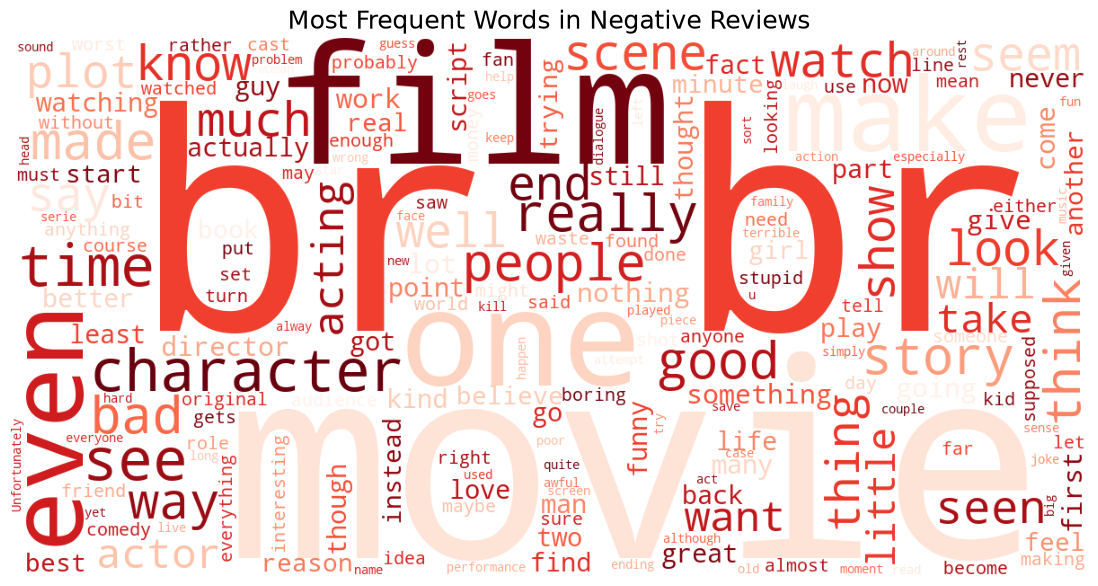

In [23]:
negative_reviews = " ".join(
    df[df["sentiment"] == "negative"]["review"]
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="Reds"
).generate(negative_reviews)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Frequent Words in Negative Reviews", fontsize=18)

plt.show()

### Observation

Negative reviews commonly contain words such as *movie*, *film*, *bad*, *worst*, and *boring*. These words reflect dissatisfaction with different aspects of the movies.

In [25]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"<.*?>", " ", text)

    text = re.sub(r"[^a-zA-Z]", " ", text)

    return text

In [26]:
all_reviews = " ".join(df["review"])

all_reviews = clean_text(all_reviews)

In [27]:
words = all_reviews.split()

word_counts = Counter(words)

top_words = word_counts.most_common(20)

top_words

[('the', 667802),
 ('and', 324344),
 ('a', 322977),
 ('of', 289344),
 ('to', 268041),
 ('is', 211012),
 ('it', 190808),
 ('in', 186720),
 ('i', 175552),
 ('this', 150950),
 ('that', 143830),
 ('s', 129745),
 ('was', 95580),
 ('as', 91734),
 ('movie', 87945),
 ('for', 87451),
 ('with', 87349),
 ('but', 83530),
 ('film', 79677),
 ('you', 69120)]

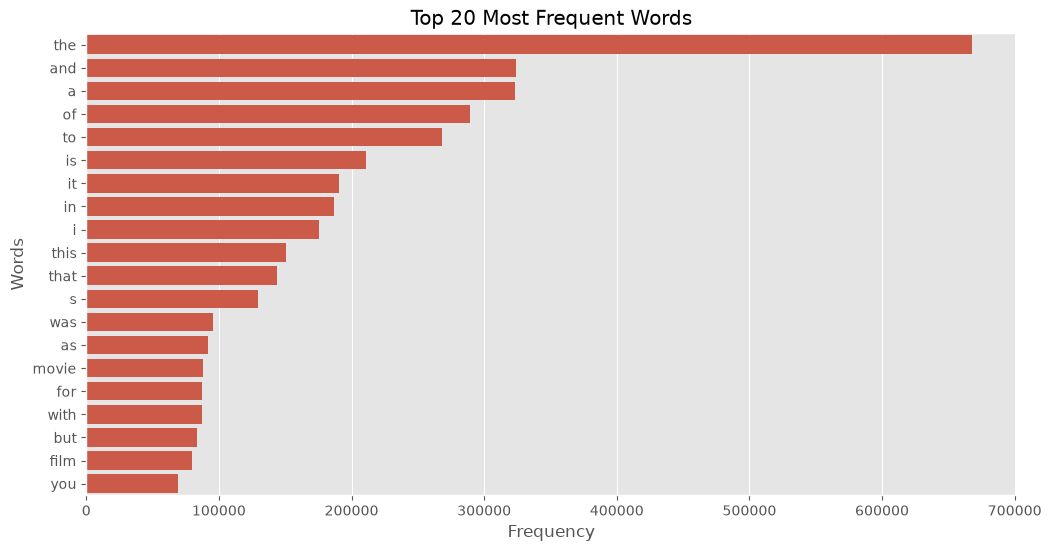

In [28]:
words = [word for word, count in top_words]

counts = [count for word, count in top_words]

plt.figure(figsize=(12,6))

sns.barplot(
    x=counts,
    y=words
)

plt.title("Top 20 Most Frequent Words")

plt.xlabel("Frequency")

plt.ylabel("Words")

plt.show()

### Observation

Common English words such as *the*, *and*, *movie*, and *film* dominate the frequency distribution. These words carry little sentiment information and will be removed during text preprocessing using stop-word removal.

In [29]:
vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words="english"
)

X = vectorizer.fit_transform(df["review"])

sum_words = X.sum(axis=0)

words_freq = [
    (word, sum_words[0, idx])
    for word, idx in vectorizer.vocabulary_.items()
]

words_freq = sorted(
    words_freq,
    key=lambda x: x[1],
    reverse=True
)[:20]

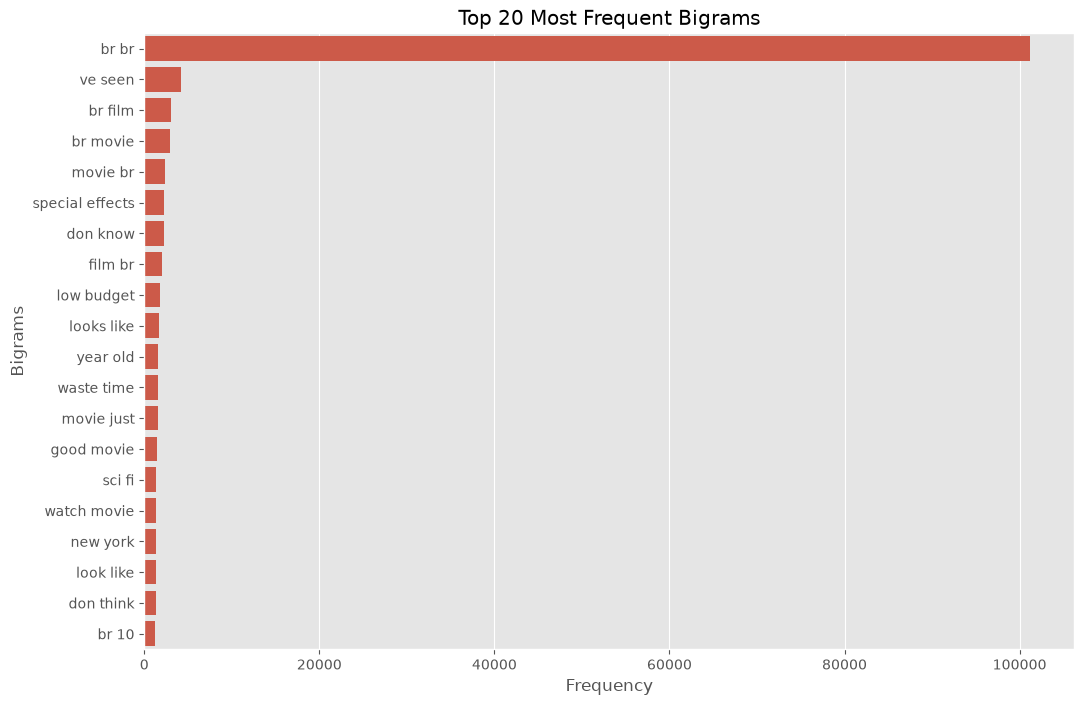

In [30]:
bigrams = [i[0] for i in words_freq]

counts = [i[1] for i in words_freq]

plt.figure(figsize=(12,8))

sns.barplot(
    x=counts,
    y=bigrams
)

plt.title("Top 20 Most Frequent Bigrams")

plt.xlabel("Frequency")

plt.ylabel("Bigrams")

plt.show()

### Observation

Frequently occurring bigrams such as *special effects*, *highly recommend*, or *waste time* provide much richer contextual information than individual words. These combinations help machine learning models understand sentiment more effectively.